# Escalado de Tamaño Finito — Modelo de Ising 2D

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq, curve_fit

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 12,
                     'lines.linewidth': 1.5, 'lines.markersize': 4})

# Cargar los 3 algoritmos
archivos = {'Metropolis': 'metropolis_2d.txt',
            'Glauber':    'glauber_2d.txt',
            'Wolff':      'wolff_2d.txt'}

cols = ['L', 'T', 'e', 'm', 'Cv', 'm2', 'm4']
data = {}
for algo, f in archivos.items():
    df = pd.read_csv(f, sep=r'\s+', header=None, names=cols)
    df['U4']  = 1.0 - df['m4'] / (3.0 * df['m2']**2)
    df['chi'] = df['L']**2 * (df['m2'] - df['m']**2)
    data[algo] = df

L_values = sorted(data['Wolff']['L'].unique())
print(f"L = {L_values}")

L = [16, 32, 64, 128]


In [9]:
# Funciones auxiliares
def linfit(x, a, b):
    return a * x + b

def find_Tc(df, L_values):
    """Cruce de Binder cumulant entre pares consecutivos de L."""
    interps = {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        # Para U4 usamos interpolacion lineal: evita cruces espurios por oscilaciones cubicas.
        interps[L] = interp1d(s['T'].values, s['U4'].values, kind='linear')
    
    crossings = []
    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        s1 = df[df['L'] == L1]; s2 = df[df['L'] == L2]
        Tlo = max(s1['T'].min(), s2['T'].min(), 1.8)
        Thi = min(s1['T'].max(), s2['T'].max(), 2.8)
        Ts = np.linspace(Tlo, Thi, 1000)
        diff = interps[L1](Ts) - interps[L2](Ts)
        for j in range(len(diff)-1):
            if diff[j] * diff[j+1] < 0:
                crossings.append(brentq(lambda t: interps[L1](t) - interps[L2](t), Ts[j], Ts[j+1]))
                break
    return np.mean(crossings), np.std(crossings), interps

def get_exponents(df, L_values, Tc):
    """Devuelve nu, beta_over_nu, gamma_over_nu."""
    interp_U4, interp_m = {}, {}
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        interp_U4[L] = interp1d(s['T'].values, s['U4'].values, kind='cubic')
        interp_m[L]  = interp1d(s['T'].values, s['m'].values,  kind='cubic')
    
    # 1/nu desde dU4/dT en Tc
    dT = 0.001
    Ls_nu, dU = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if Tc - dT >= s['T'].min() and Tc + dT <= s['T'].max():
            deriv = abs((interp_U4[L](Tc+dT) - interp_U4[L](Tc-dT)) / (2*dT))
            Ls_nu.append(L); dU.append(deriv)
    p_nu, _ = curve_fit(linfit, np.log(Ls_nu), np.log(dU))
    nu = 1.0 / p_nu[0]
    
    # beta/nu desde m(Tc)
    Ls_m, ms = [], []
    for L in L_values:
        s = df[df['L'] == L]
        if s['T'].min() <= Tc <= s['T'].max():
            Ls_m.append(L); ms.append(interp_m[L](Tc))
    p_m, _ = curve_fit(linfit, np.log(Ls_m), np.log(ms))
    beta_over_nu = -p_m[0]
    
    # gamma/nu desde chi_max
    Ls_chi, chi_maxs = [], []
    for L in L_values:
        s = df[df['L'] == L]
        Ls_chi.append(L); chi_maxs.append(s['chi'].max())
    p_chi, _ = curve_fit(linfit, np.log(Ls_chi), np.log(chi_maxs))
    gamma_over_nu = p_chi[0]
    
    return nu, beta_over_nu, gamma_over_nu

In [10]:
# Calcular Tc y exponentes para cada algoritmo
results = {}
for algo, df in data.items():
    Tc, Tc_err, interps = find_Tc(df, L_values)
    nu, bn, gn = get_exponents(df, L_values, Tc)
    results[algo] = {'Tc': Tc, 'Tc_err': Tc_err, 'nu': nu,
                     'beta_over_nu': bn, 'gamma_over_nu': gn,
                     'beta': bn * nu, 'gamma': gn * nu}
    print(f"\n{algo}:")
    print(f"  Tc = {Tc:.4f} ± {Tc_err:.4f}")
    print(f"  ν = {nu:.4f},  β = {bn*nu:.4f},  γ = {gn*nu:.4f}")
    print(f"  β/ν = {bn:.4f},  γ/ν = {gn:.4f}")
    print(f"  Hiperescalado γ/ν + 2β/ν = {gn + 2*bn:.4f}")


Metropolis:
  Tc = 2.2485 ± 0.0110
  ν = 1.1661,  β = 0.0794,  γ = 2.2378
  β/ν = 0.0681,  γ/ν = 1.9191
  Hiperescalado γ/ν + 2β/ν = 2.0554

Glauber:
  Tc = 2.2753 ± 0.0151
  ν = 0.7341,  β = 0.0767,  γ = 1.0705
  β/ν = 0.1044,  γ/ν = 1.4583
  Hiperescalado γ/ν + 2β/ν = 1.6672

Wolff:
  Tc = 2.2746 ± 0.0041
  ν = 0.6530,  β = 0.0912,  γ = 1.1321
  β/ν = 0.1396,  γ/ν = 1.7338
  Hiperescalado γ/ν + 2β/ν = 2.0130


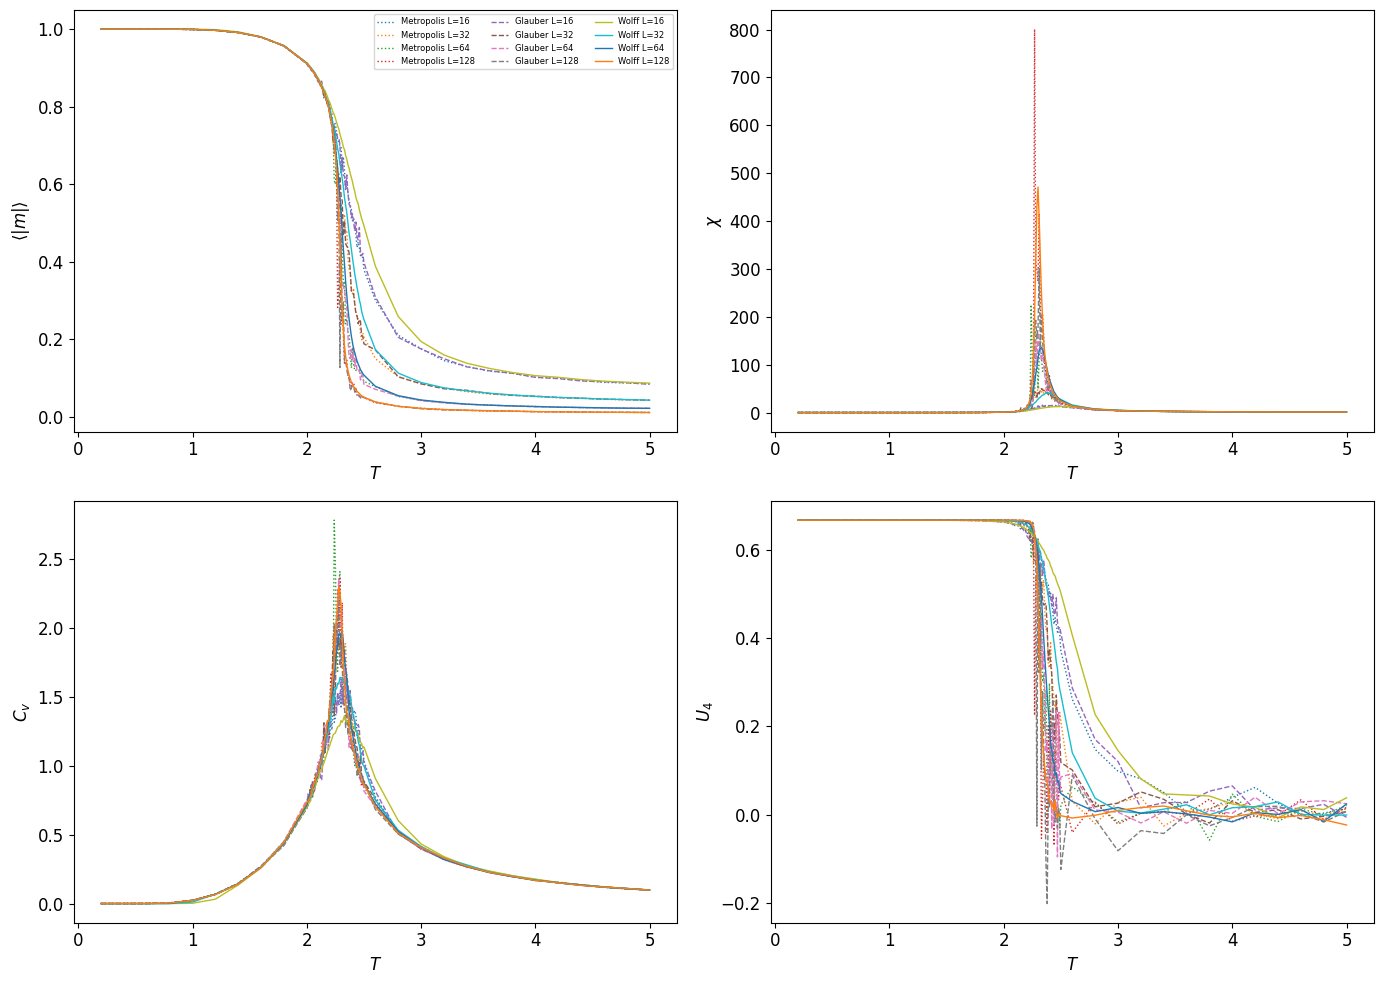

In [11]:
# Observables vs T (2x2 por algoritmo, superpuesto)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
obs = [('m', r'$\langle |m| \rangle$'), ('chi', r'$\chi$'),
       ('Cv', r'$C_v$'), ('U4', r'$U_4$')]

for ax, (col, ylabel) in zip(axes.flat, obs):
    for algo, df in data.items():
        for L in L_values:
            s = df[df['L'] == L].sort_values('T')
            label = f'{algo} L={L}' if col == 'm' else None
            ls = '-' if algo == 'Wolff' else ('--' if algo == 'Glauber' else ':')
            ax.plot(s['T'], s[col], ls, ms=2, lw=1, label=label)
    ax.set_xlabel(r'$T$'); ax.set_ylabel(ylabel)

axes[0,0].legend(fontsize=6, ncol=3)
plt.tight_layout(); plt.show()

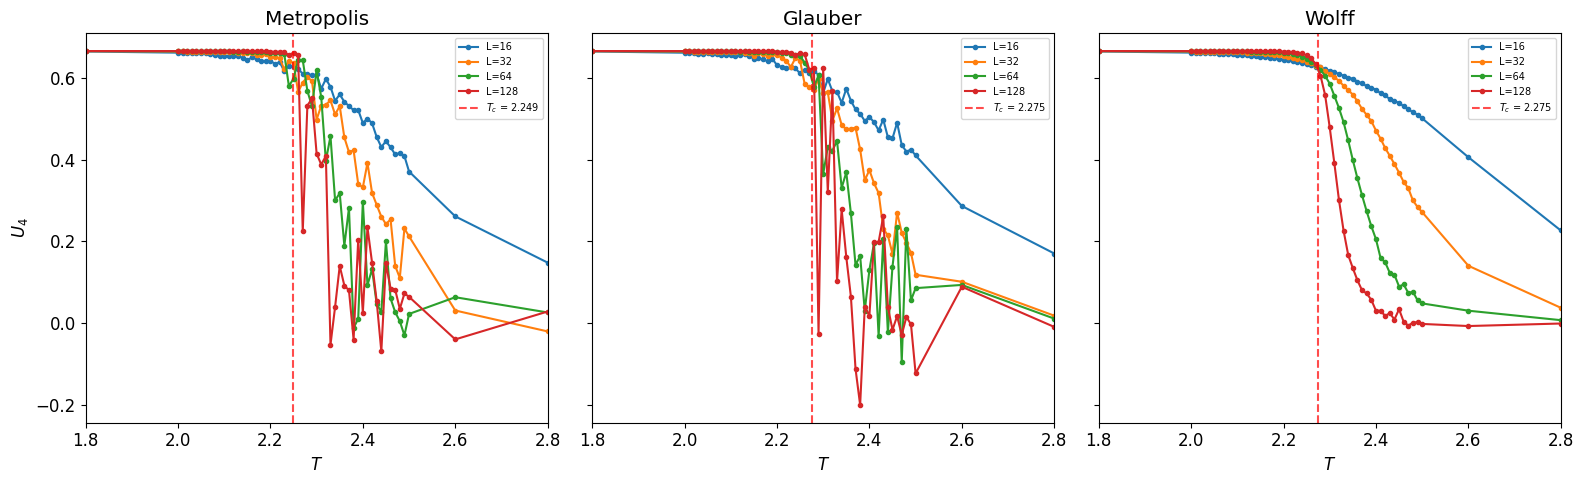

In [12]:
# Cumulante de Binder — un panel por algoritmo
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (algo, df) in zip(axes, data.items()):
    r = results[algo]
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        ax.plot(s['T'], s['U4'], 'o-', ms=3, label=f'L={L}')
    ax.axvline(r['Tc'], color='red', ls='--', alpha=0.7,
               label=f'$T_c$ = {r["Tc"]:.3f}')
    ax.set_xlim(1.8, 2.8)
    ax.set_xlabel(r'$T$'); ax.set_title(algo)
    ax.legend(fontsize=7)

axes[0].set_ylabel(r'$U_4$')
plt.tight_layout(); plt.show()

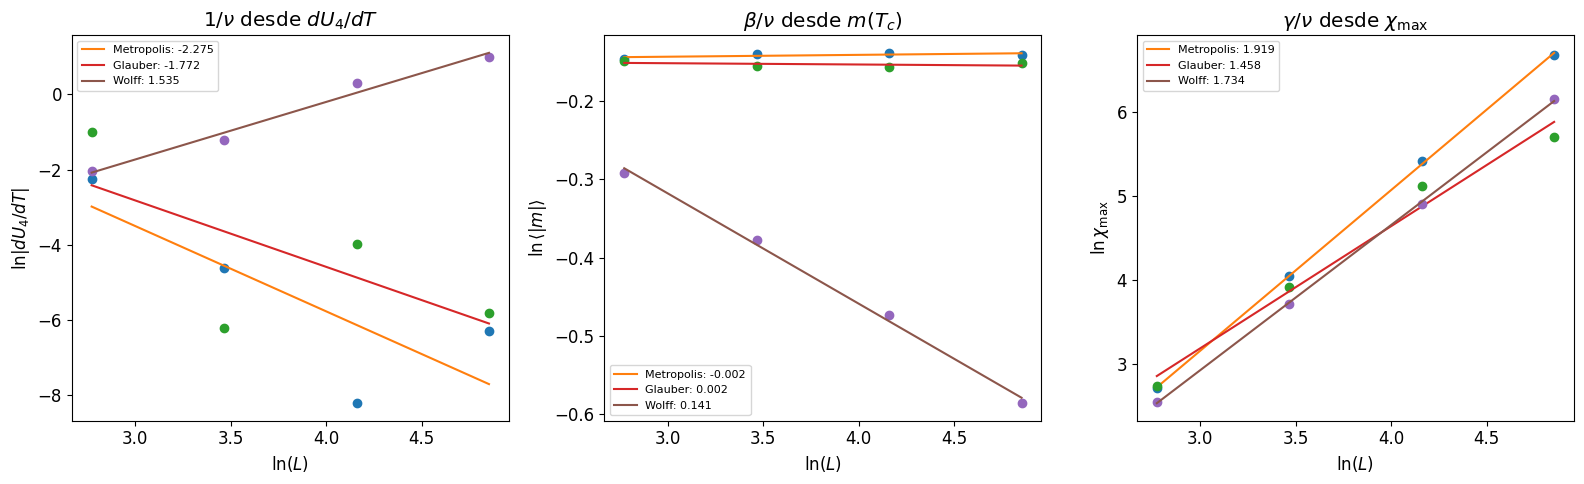

In [6]:
# Ajustes log-log: ν, β/ν, γ/ν — un panel por exponente, 3 algoritmos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = [r'$1/\nu$ desde $dU_4/dT$', r'$\beta/\nu$ desde $m(T_c)$',
          r'$\gamma/\nu$ desde $\chi_{\max}$']

for algo, df in data.items():
    r = results[algo]; Tc = r['Tc']
    
    # dU4/dT
    dT = 0.001; Ls, vals = [], []
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        f = interp1d(s['T'].values, s['U4'].values, kind='cubic')
        if Tc - dT >= s['T'].min() and Tc + dT <= s['T'].max():
            Ls.append(L); vals.append(abs((f(Tc+dT)-f(Tc-dT))/(2*dT)))
    p, _ = curve_fit(linfit, np.log(Ls), np.log(vals))
    axes[0].plot(np.log(Ls), np.log(vals), 'o', ms=6)
    x = np.linspace(np.log(min(Ls)), np.log(max(Ls)), 50)
    axes[0].plot(x, linfit(x, *p), '-', label=f'{algo}: {p[0]:.3f}')
    
    # m(Tc)
    Ls, vals = [], []
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        f = interp1d(s['T'].values, s['m'].values, kind='cubic')
        if s['T'].min() <= Tc <= s['T'].max():
            Ls.append(L); vals.append(f(Tc))
    p, _ = curve_fit(linfit, np.log(Ls), np.log(vals))
    axes[1].plot(np.log(Ls), np.log(vals), 'o', ms=6)
    x = np.linspace(np.log(min(Ls)), np.log(max(Ls)), 50)
    axes[1].plot(x, linfit(x, *p), '-', label=f'{algo}: {-p[0]:.3f}')
    
    # chi_max
    Ls, vals = [], []
    for L in L_values:
        s = df[df['L'] == L]
        Ls.append(L); vals.append(s['chi'].max())
    p, _ = curve_fit(linfit, np.log(Ls), np.log(vals))
    axes[2].plot(np.log(Ls), np.log(vals), 'o', ms=6)
    x = np.linspace(np.log(min(Ls)), np.log(max(Ls)), 50)
    axes[2].plot(x, linfit(x, *p), '-', label=f'{algo}: {p[0]:.3f}')

for ax, t in zip(axes, titles):
    ax.set_xlabel(r'$\ln(L)$'); ax.set_title(t); ax.legend(fontsize=8)

axes[0].set_ylabel(r'$\ln|dU_4/dT|$')
axes[1].set_ylabel(r'$\ln\langle|m|\rangle$')
axes[2].set_ylabel(r'$\ln\chi_{\max}$')
plt.tight_layout(); plt.show()

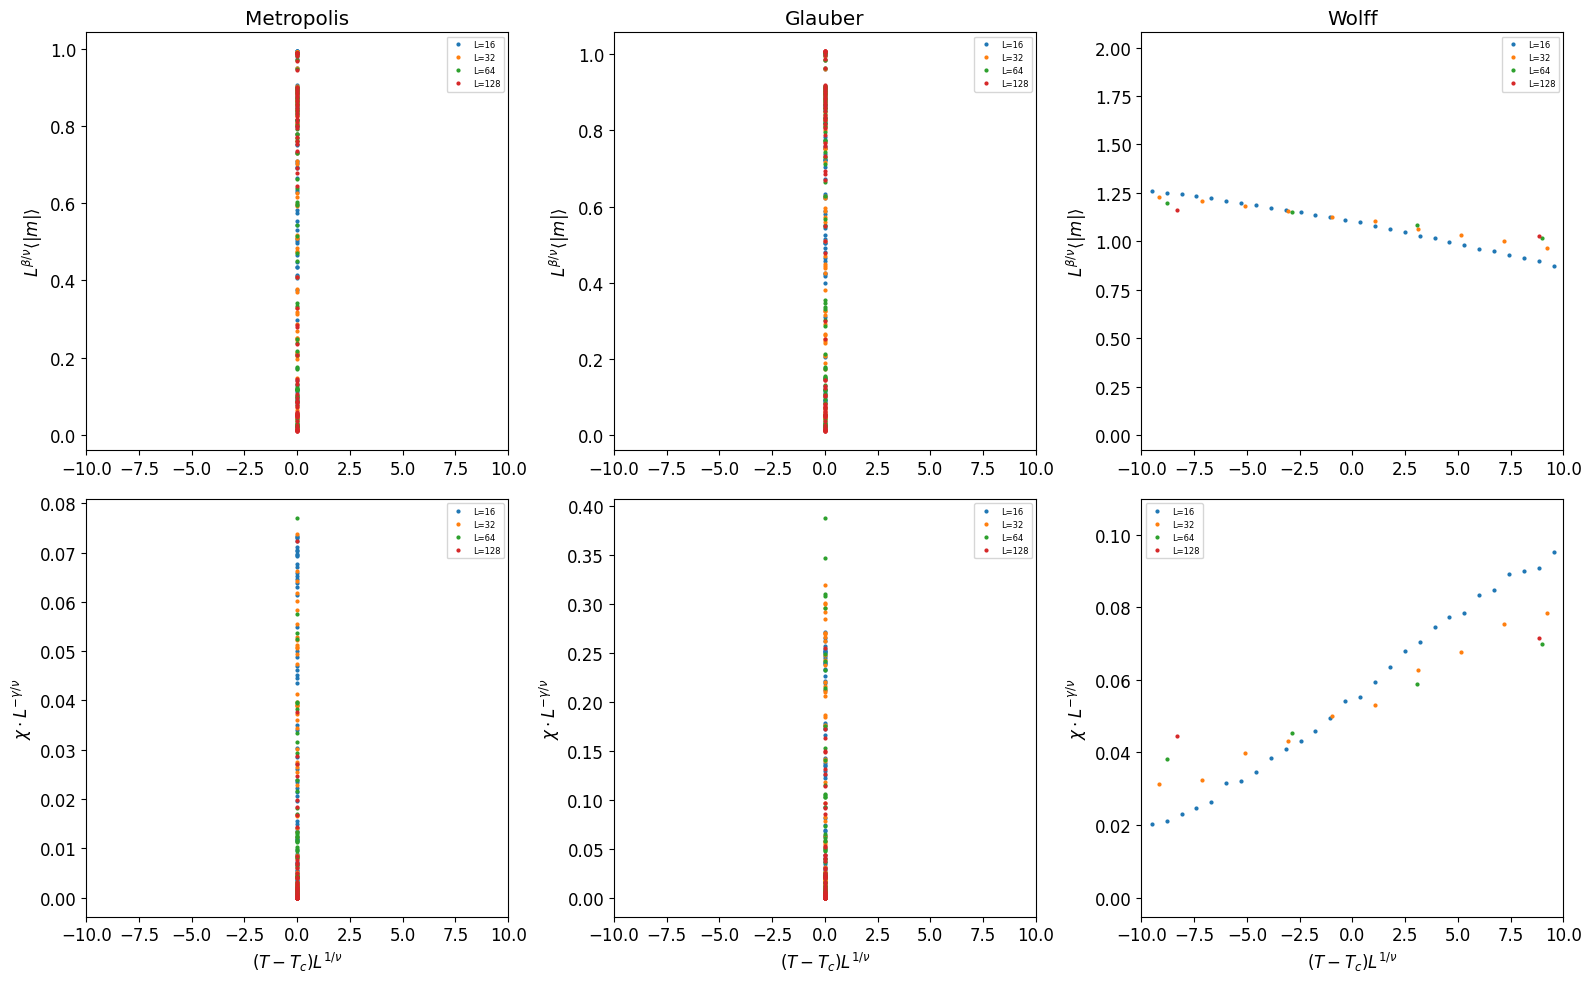

In [7]:
# Colapso de datos — magnetización y susceptibilidad, un panel por algoritmo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for j, (algo, df) in enumerate(data.items()):
    r = results[algo]
    Tc, nu = r['Tc'], r['nu']
    bn, gn = r['beta_over_nu'], r['gamma_over_nu']
    
    for L in L_values:
        s = df[df['L'] == L].sort_values('T')
        t_sc = (s['T'] - Tc) * L**(1.0/nu)
        
        axes[0, j].plot(t_sc, s['m'] * L**bn, 'o', ms=2, label=f'L={L}')
        axes[1, j].plot(t_sc, s['chi'] * L**(-gn), 'o', ms=2, label=f'L={L}')
    
    axes[0, j].set_title(algo)
    axes[0, j].set_xlim(-10, 10); axes[1, j].set_xlim(-10, 10)
    axes[0, j].legend(fontsize=6); axes[1, j].legend(fontsize=6)

for ax in axes[0, :]:
    ax.set_ylabel(r'$L^{\beta/\nu}\langle|m|\rangle$')
for ax in axes[1, :]:
    ax.set_xlabel(r'$(T-T_c)L^{1/\nu}$')
    ax.set_ylabel(r'$\chi \cdot L^{-\gamma/\nu}$')

plt.tight_layout(); plt.show()

In [8]:
# Tabla resumen
print(f"{'Algoritmo':<12} {'Tc':>8} {'ν':>8} {'β':>8} {'γ':>8} {'β/ν':>8} {'γ/ν':>8} {'γ/ν+2β/ν':>10}")
print("-" * 76)
for algo, r in results.items():
    hs = r['gamma_over_nu'] + 2*r['beta_over_nu']
    print(f"{algo:<12} {r['Tc']:>8.4f} {r['nu']:>8.4f} {r['beta']:>8.4f} "
          f"{r['gamma']:>8.4f} {r['beta_over_nu']:>8.4f} {r['gamma_over_nu']:>8.4f} {hs:>10.4f}")

Algoritmo          Tc        ν        β        γ      β/ν      γ/ν   γ/ν+2β/ν
----------------------------------------------------------------------------
Metropolis     2.0984  -0.4395   0.0010  -0.8434  -0.0024   1.9191     1.9143
Glauber        2.1174  -0.5645  -0.0009  -0.8232   0.0016   1.4583     1.4616
Wolff          2.2748   0.6515   0.0918   1.1295   0.1409   1.7338     2.0156
